In [2]:
from pathlib import Path
from io import BytesIO
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from PIL import Image as PILImage
from IPython.display import display, Image as DisplayImage, Markdown
import re # for string cleaning
import netCDF4 as nc
import glob
import os
import random

In [3]:
CHIP_DIR = '/explore/nobackup/projects/pix4dcloud/scratch/abi-cloudsat-crop-test-inner-disk-2400/'

In [4]:
def open_npz_file(npz_path):
    try:
        archive = np.load(npz_path, allow_pickle=True)
        return archive
    except Exception as e:
        print(f"Error opening {npz_path}: {str(e)}")
        return None

# Function to find all npz files in a directory
def find_npz_files(directory_path):
    """Find all .npz files in a directory"""
    npz_pattern = os.path.join(directory_path, "*.npz")
    npz_files = glob.glob(npz_pattern)
    npz_files.sort()  
    return npz_files

In [5]:
files = find_npz_files(CHIP_DIR)

print(files)
print(len(files))


# start = 0

# n = 50 # number of chips you want to have

# files = files[start:start+n]

['/explore/nobackup/projects/pix4dcloud/scratch/abi-cloudsat-crop-test-inner-disk-2400/GOES16_east_abi_cloudsat_20190410T165028Z_orbit68982_r5098_c8446_p18810_len489.npz', '/explore/nobackup/projects/pix4dcloud/scratch/abi-cloudsat-crop-test-inner-disk-2400/GOES16_east_abi_cloudsat_20190410T165035Z_orbit68982_r5051_c8436_p18855_len490.npz', '/explore/nobackup/projects/pix4dcloud/scratch/abi-cloudsat-crop-test-inner-disk-2400/GOES16_east_abi_cloudsat_20190410T165042Z_orbit68982_r5004_c8426_p18900_len490.npz', '/explore/nobackup/projects/pix4dcloud/scratch/abi-cloudsat-crop-test-inner-disk-2400/GOES16_east_abi_cloudsat_20190410T165049Z_orbit68982_r4957_c8415_p18945_len491.npz', '/explore/nobackup/projects/pix4dcloud/scratch/abi-cloudsat-crop-test-inner-disk-2400/GOES16_east_abi_cloudsat_20190410T165056Z_orbit68982_r4910_c8405_p18990_len491.npz', '/explore/nobackup/projects/pix4dcloud/scratch/abi-cloudsat-crop-test-inner-disk-2400/GOES16_east_abi_cloudsat_20190410T165104Z_orbit68982_r4863

In [6]:
bands = {
    
0: 'Blue',
1: 'Red',
2: 'Veggie',
3: 'Cirrus',
4: 'Snow/Ice',
5: 'Cloud particle size',
6: 'Shortwave window',
7: 'Upper-level water vapor',
8: 'Midlevel water vapor',
9: 'Lower-level water vapor',
10: 'Cloud-top phase',
11: 'Ozone',
12: '"Clean" longwave window',
13: 'Longwave window',
14: '"Dirty" longwave window',
15: 'CO2 longwave',

}



In [7]:
allVals = [[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]

# allVals = np.zeros((16, 0))

print(allVals)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]


In [8]:
def createHist(data, bandName):
    # Create a basic histogram
    plt.hist(data)

    # Add titles and labels
    plt.title(bandName)
    plt.xlabel('Values')
    plt.ylabel('Frequency')

    # Display the chart
    plt.show()

In [ ]:


for file in files:
    # print(file)
    archive = open_npz_file(file)


    # print(archive.files)

    chip = archive['ABI/chip']
    # print(chip.shape)

    for timestep in range(5):
        for band in range(16):
            # print(timestep, band)
            # print(chip[timestep, :, :, band])


            # [timestep, ::8, ::8, band] takes every 8th pixel in both height and width.
            # This uses 64x less memory and prevents the MemoryError.
            allVals[band].append(chip[timestep, ::8, ::8, band].flatten())


# print(len(allVals[15]))



In [9]:


for file in files:
    # print(file)
    archive = open_npz_file(file)


    # print(archive.files)

    chip = archive['ABI/chip']
    # print(chip.shape)

    
    for band in range(16):
            # print(timestep, band)
            # print(chip[timestep, :, :, band])


            # [timestep, ::8, ::8, band] takes every 8th pixel in both height and width.
            # This uses 64x less memory and prevents the MemoryError.
        allVals[band].append(chip[:, ::8, ::8, band].flatten())


# print(len(allVals[15]))



In [10]:
allVals = [np.concatenate(band_vals) for band_vals in allVals]

In [11]:
for i, band in enumerate(allVals):
    print(np.isnan(allVals[i]).any())
    print(len(allVals[i]))

False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040
False
2519040


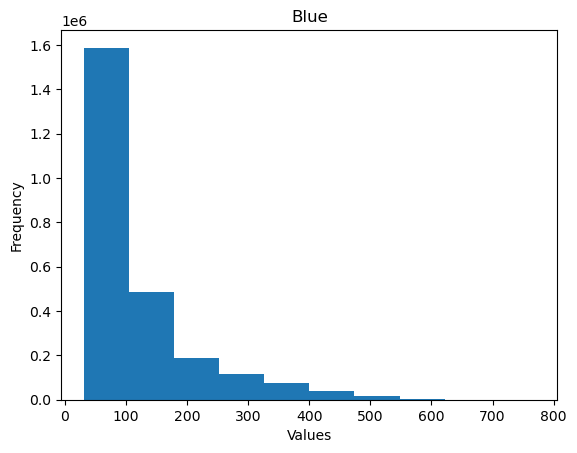

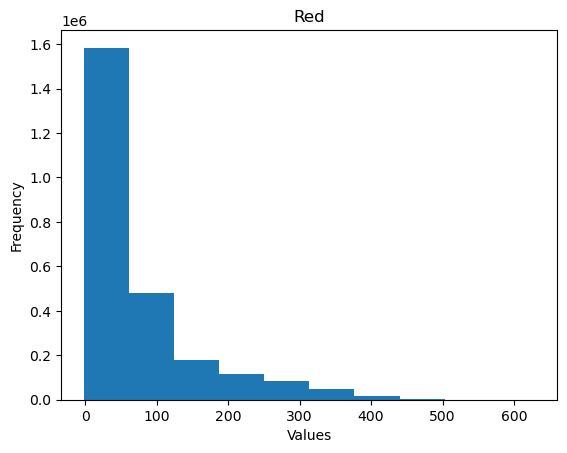

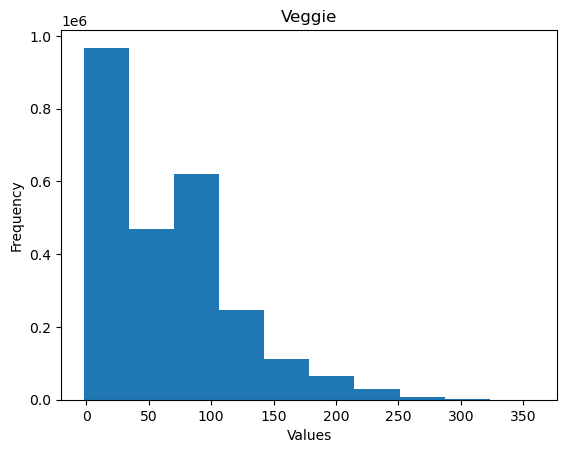

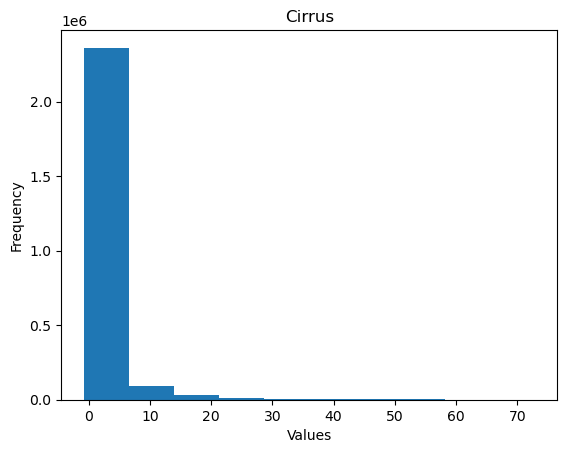

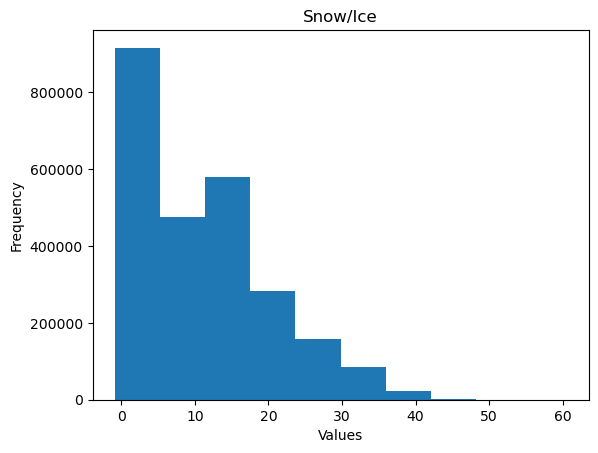

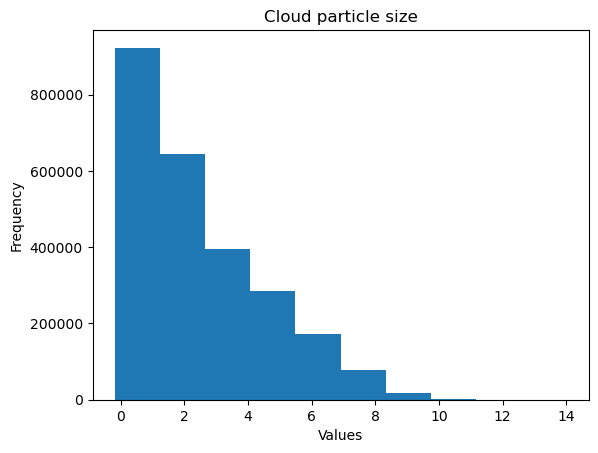

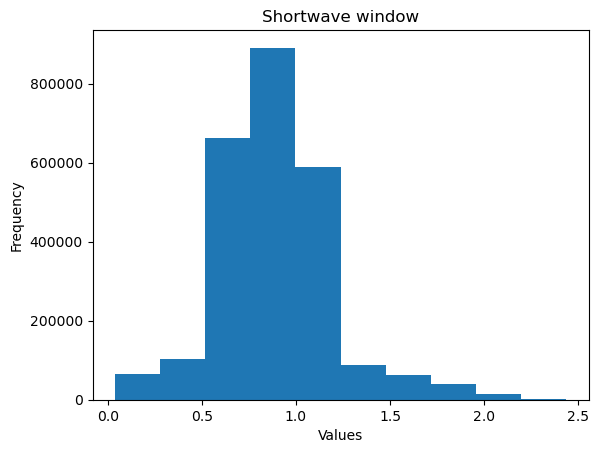

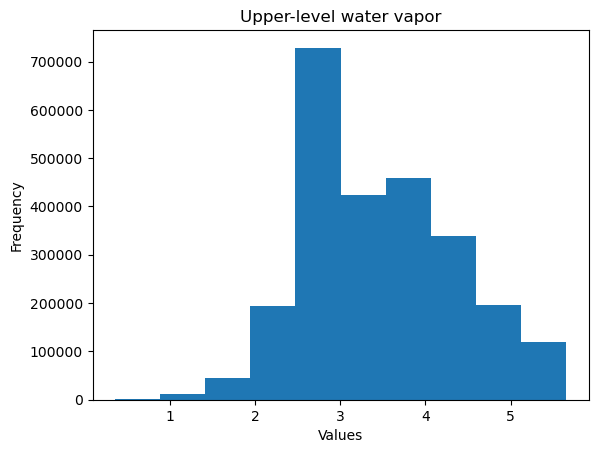

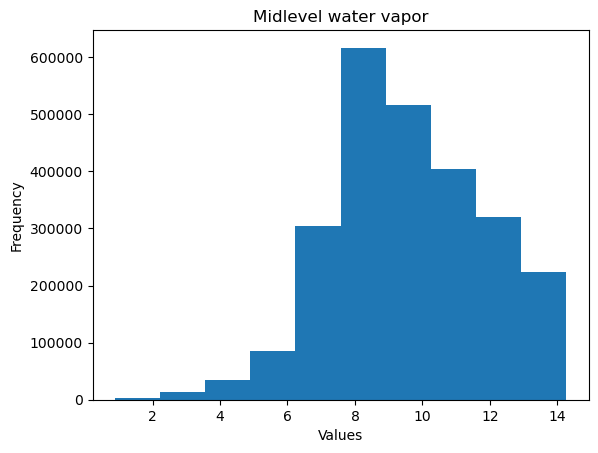

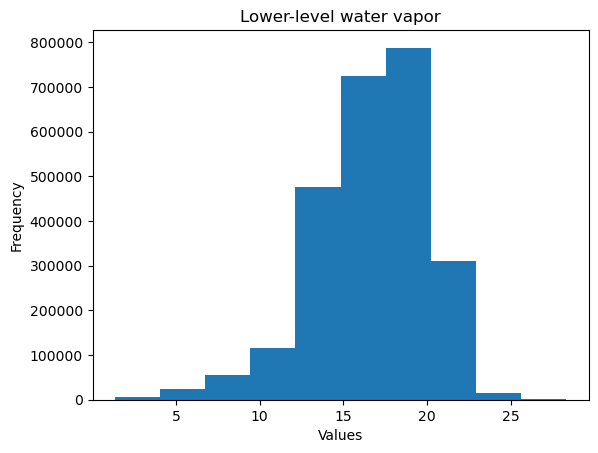

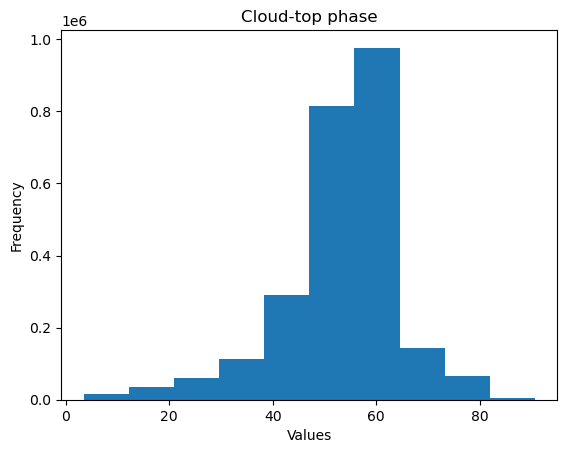

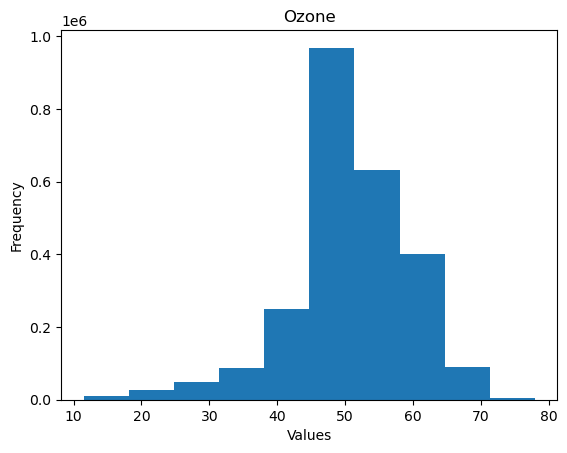

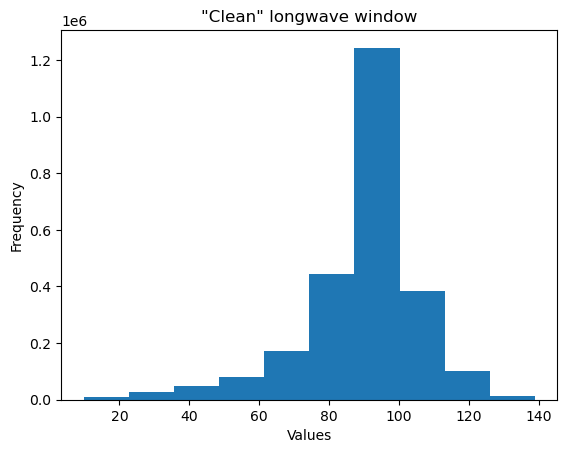

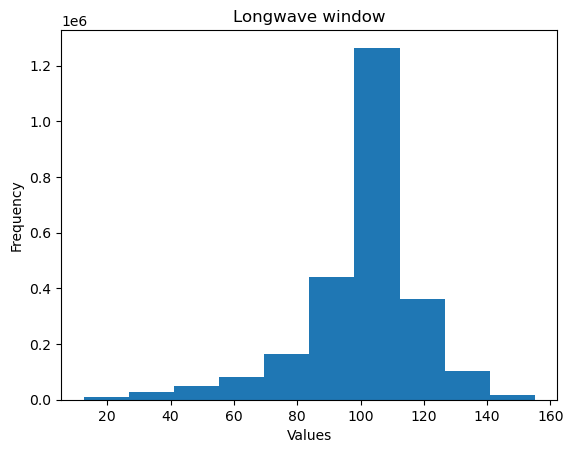

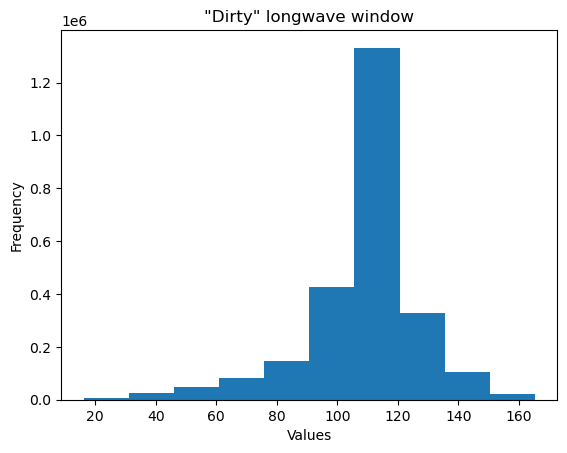

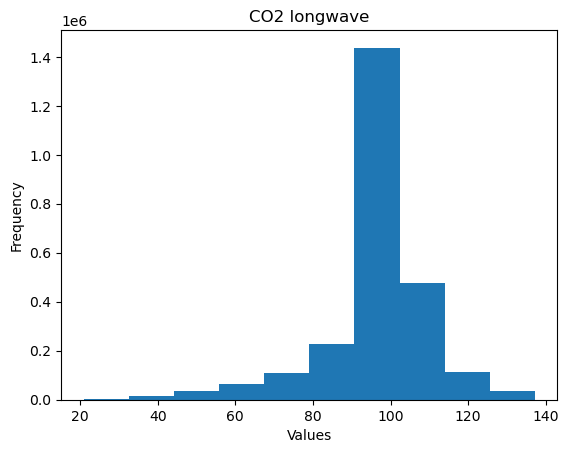

In [12]:
for i, band in enumerate(allVals):
    createHist(allVals[i], bands[i])